Dataset:
    study_hours  attendance  previous_score  result
0            2          60              45       0
1            5          80              70       1
2            1          50              40       0
3            8          90              85       1
4            6          85              78       1
5            3          65              50       0
6            7          88              80       1
7            4          70              60       1
8            9          95              90       1
9            2          55              42       0
Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

Confusion Matrix:

[[2]]

Predicted Result for New Student: Pass


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


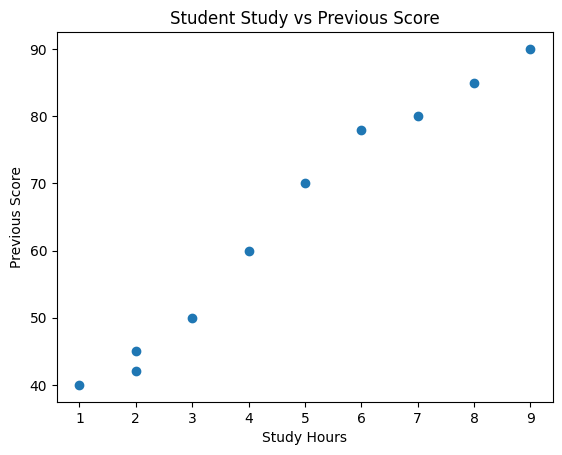

In [19]:
# Student Result Analyzer-Full ML Project Code
# Author: Emon Khan
# Description: End-to-end ML project to analyze & predict student results

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Create / Load Dataset

data = {
    "study_hours": [2, 5, 1, 8, 6, 3, 7, 4, 9, 2],
    "attendance": [60, 80, 50, 90, 85, 65, 88, 70, 95, 55],
    "previous_score": [45, 70, 40, 85, 78, 50, 80, 60, 90, 42],
    "result": [0, 1, 0, 1, 1, 0, 1, 1, 1, 0]
}

df = pd.DataFrame(data)
print("Dataset:\n", df)

# 3. Feature & Target Split

X = df[["study_hours", "attendance", "previous_score"]]
y = df["result"]

# 4. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train ML Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# 7. Predictions
y_pred = model.predict(X_test_scaled)

# 8. Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# 9. Student Result Prediction Function
def predict_student_result(study_hours, attendance, previous_score):
    input_data = np.array([[study_hours, attendance, previous_score]])
    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)

    if prediction[0] == 1:
        return "Pass"
    else:
        return "Fail"

# 10. Test with New Student Data
result = predict_student_result(
    study_hours=6,
    attendance=82,
    previous_score=75
)

print("\nPredicted Result for New Student:", result)

# 11. Optional: Visualization
plt.figure()
plt.scatter(df["study_hours"], df["previous_score"])
plt.xlabel("Study Hours")
plt.ylabel("Previous Score")
plt.title("Student Study vs Previous Score")
plt.show()
